In [2]:
import numpy as np
from scipy.spatial.distance import euclidean
from sklearn.metrics import jaccard_score
from numpy import dot
from numpy.linalg import norm

In [3]:
p = np.array([2, 3, 5])  # вектор в 3D пространстве
q = np.array([1, 0, 4])  # другой вектор в 3D

# Евклидово расстояние - "прямое расстояние" между точками
# Формула: sqrt((2-1)² + (3-0)² + (5-4)²) = sqrt(1 + 9 + 1) = sqrt(11) ≈ 3.317

In [4]:
eucl_dist = euclidean(p, q)
print(f"Евклидово расстояние: {eucl_dist:.3f}")

Евклидово расстояние: 3.317


Схожесть Жаккара - для бинарных данных (0 и 1)

In [5]:
A = np.array([1, 1, 0, 1])  # первый набор
B = np.array([1, 0, 1, 1])  # второй набор

# Формула: (совпадающие 1) / (все 1 в обоих наборах)
# Совпадения: позиции 0 и 3 = 2 совпадения
# Все 1: позиции 0,1,2,3 = 4 позиции
# Результат: 2/4 = 0.5

In [6]:
jacc_sim = jaccard_score(A, B)
print(f"Схожесть Жаккара: {jacc_sim:.3f}")

Схожесть Жаккара: 0.500


Косинусная схожесть - угол между векторами
# Формула: (p·q) / (||p|| * ||q||)
# p·q = 2*1 + 3*0 + 5*4 = 22
# ||p|| = sqrt(2² + 3² + 5²) = sqrt(38) ≈ 6.164
# ||q|| = sqrt(1² + 0² + 4²) = sqrt(17) ≈ 4.123
# Результат: 22 / (6.164 * 4.123) ≈ 0.866

In [10]:
cos_sim = dot(p, q) / (norm(p) * norm(q))
print(f"Косинусная схожесть: {cos_sim:.3f}")

Косинусная схожесть: 0.866


Корреляция - линейная связь между векторами

In [11]:
corr = np.corrcoef(p, q)[0, 1]
print(f"Корреляция: {corr:.3f}")

Корреляция: 0.839


Корреляция - это мера того, насколько изменения одного вектора связаны с изменениями другого.

corr = Σ[(p_i - mean_p) * (q_i - mean_q)] / (std_p * std_q * (n-1))

Корреляция = 0.839 означает:

Знак + = положительная связь (когда p растет, q тоже растет)



In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

In [14]:
data = load_iris()
X = data.data[:, :3]  # берем только 3 признака из 4 для простоты
print(f"Размер данных: {X.shape}")  # (150, 3) - 150 цветков, 3 признака

Размер данных: (150, 3)


# Приводим все признаки к одинаковому масштабу (среднее=0, стандартное отклонение=1)

In [15]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
print(f"После стандартизации - среднее: {X_std.mean():.3f}")

После стандартизации - среднее: -0.000


# Ковариационная матрица - показывает связи между признаками

In [28]:
cov_mat = np.cov(X_std.T)
print("Ковариационная матрица:")
print(cov_mat)

Ковариационная матрица:
[[ 1.00671141 -0.11835884  0.87760447]
 [-0.11835884  1.00671141 -0.43131554]
 [ 0.87760447 -0.43131554  1.00671141]]


Показывает, как признаки связаны друг с другом

Диагональ = дисперсия каждого признака

Остальные ячейки = ковариация между признаками

In [29]:
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)

Сортируем по убыванию важности

In [30]:
idx = np.argsort(eigen_vals)[::-1]  # индексы для сортировки
eigen_vals_sorted = eigen_vals[idx]
eigen_vecs_sorted = eigen_vecs[:, idx]

In [31]:
print(f"Собственные значения: {eigen_vals_sorted}")

Собственные значения: [2.0349965  0.91352474 0.07161299]


Выбираем 2 главных компонента

In [32]:
W = eigen_vecs_sorted[:, :2]  # матрица проекции 3D -> 2D

Проецируем данные в 2D пространство

In [33]:
X_pca = X_std.dot(W)
print(f"После PCA: {X_pca.shape}")  # (150, 2) - из 3D в 2D!

После PCA: (150, 2)


Анализ - сколько информации сохранили

In [34]:
total_var = np.sum(eigen_vals_sorted)
explained_var = eigen_vals_sorted / total_var
print(f"Объясненная дисперсия: {explained_var}")
print(f"Первые 2 компоненты объясняют {np.sum(explained_var[:2])*100:.1f}% дисперсии")

Объясненная дисперсия: [0.67380995 0.30247819 0.02371186]
Первые 2 компоненты объясняют 97.6% дисперсии


Визуализация

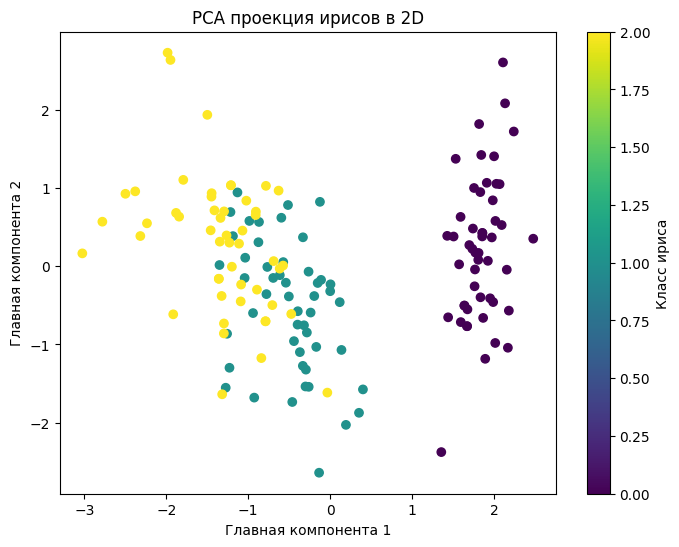

In [35]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data.target, cmap='viridis')
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.title('PCA проекция ирисов в 2D')
plt.colorbar(label='Класс ириса')
plt.show()

По всего 2 параметрам (главным компонентам) можно отличить виды ирисов с 96% точностью!

Вместо 4 измерений (длина/ширина чашелистика/лепестка) достаточно 2 "умных" параметров, которые PCA нашёл автоматически

# 3 Supervised Machine Learning


In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score
# from sklearn.datasets import load_iris

# # 2. Загрузка данных
# X, y = load_iris(return_X_y=True)
# print(f"Данные: {X.shape}, Метки: {y.shape}")

# # 70% - обучение, 30% - тестирование
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.3, random_state=42
# )
# print(f"Обучающая выборка: {X_train.shape}")
# print(f"Тестовая выборка: {X_test.shape}")

# # 4. Создаем модели для сравнения
# models = {
#     "Логистическая регрессия": LogisticRegression(max_iter=1000),
#     "k-ближайших соседей": KNeighborsClassifier(n_neighbors=5),
#     "Дерево решений": DecisionTreeClassifier(random_state=42),
#     "Метод опорных векторов": SVC(kernel='rbf')
# }

# results = {}
# for name, model in models.items():
#     model.fit(X_train, y_train)
    
#     y_pred = model.predict(X_test)
    
#     accuracy = accuracy_score(y_test, y_pred)
#     results[name] = accuracy
    
#     print(f"{name}: {accuracy:.3f}")

# best_model = max(results, key=results.get)
# print(f"\n Лучшая модель: {best_model} с точностью {results[best_model]:.3f}")

Данные: (150, 4), Метки: (150,)
Обучающая выборка: (105, 4)
Тестовая выборка: (45, 4)
Логистическая регрессия: 1.000
k-ближайших соседей: 1.000
Дерево решений: 1.000
Метод опорных векторов: 1.000

 Лучшая модель: Логистическая регрессия с точностью 1.000


In [66]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

Загрузка и подготовка данных

In [67]:
wine = load_wine()
X, y = wine.data, wine.target

In [68]:
print(f" Данные: {X.shape}") 
print(f" Классы: {wine.target_names}")
print(f" Признаки: {wine.feature_names[:5]}...")

 Данные: (178, 13)
 Классы: ['class_0' 'class_1' 'class_2']
 Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium']...


Разделяем на обучение/тест

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n Обучающая выборка: {X_train.shape}")
print(f" Тестовая выборка: {X_test.shape}")


 Обучающая выборка: (124, 13)
 Тестовая выборка: (54, 13)


Визуализируем сложность данных:

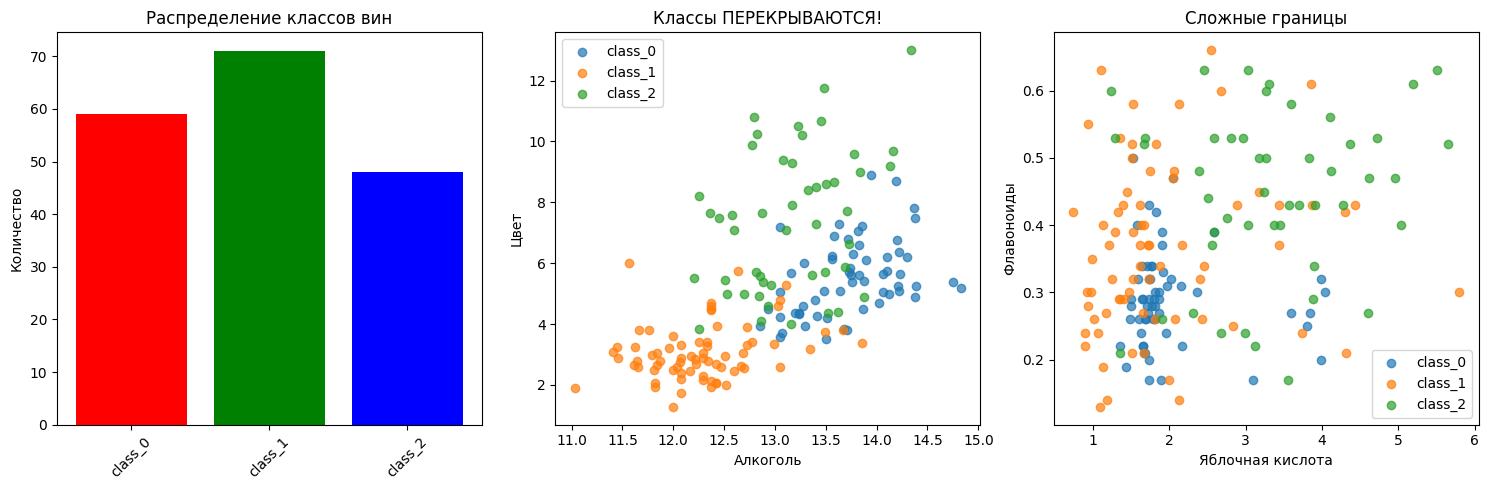

In [71]:
plt.figure(figsize=(15, 5))

# 1. Распределение классов
plt.subplot(1, 3, 1)
unique, counts = np.unique(y, return_counts=True)
plt.bar(unique, counts, color=['red', 'green', 'blue'])
plt.xticks(unique, wine.target_names, rotation=45)
plt.title('Распределение классов вин')
plt.ylabel('Количество')

# 2. Пример признаков 
plt.subplot(1, 3, 2)
for i in range(3):
    mask = (y == i)
    plt.scatter(X[mask, 0], X[mask, 9], label=wine.target_names[i], alpha=0.7)
plt.xlabel('Алкоголь')
plt.ylabel('Цвет')
plt.title('Классы ПЕРЕКРЫВАЮТСЯ!')
plt.legend()

# 3. Другие признаки
plt.subplot(1, 3, 3)
for i in range(3):
    mask = (y == i)
    plt.scatter(X[mask, 1], X[mask, 7], label=wine.target_names[i], alpha=0.7)
plt.xlabel('Яблочная кислота')
plt.ylabel('Флавоноиды')
plt.title('Сложные границы')
plt.legend()

plt.tight_layout()
plt.show()

Создаем и обучаем модели

In [72]:
models = {
    "Логистическая регрессия": LogisticRegression(max_iter=1000, random_state=42),
    "k-Ближайших соседей": KNeighborsClassifier(n_neighbors=5),
    "Дерево решений": DecisionTreeClassifier(random_state=42),
    "Метод опорных векторов": SVC(kernel='rbf', random_state=42)
}

Обучение и оценка

In [73]:
print("\n РЕЗУЛЬТАТЫ НА СЛОЖНЫХ ДАННЫХ:")
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f" {name}: {accuracy:.3f} ({accuracy*100:.1f}%)")


 РЕЗУЛЬТАТЫ НА СЛОЖНЫХ ДАННЫХ:
 Логистическая регрессия: 0.981 (98.1%)
 k-Ближайших соседей: 0.722 (72.2%)
 Дерево решений: 0.963 (96.3%)
 Метод опорных векторов: 0.667 (66.7%)


c:\Users\Nurza\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Анализ

In [62]:
best_model = max(results, key=results.get)
worst_model = min(results, key=results.get)
print(f"\n ЛУЧШАЯ МОДЕЛЬ: {best_model} - {results[best_model]:.3f}")
print(f" ХУДШАЯ МОДЕЛЬ: {worst_model} - {results[worst_model]:.3f}")


 ЛУЧШАЯ МОДЕЛЬ: Логистическая регрессия - 0.981
 ХУДШАЯ МОДЕЛЬ: Метод опорных векторов - 0.667


 ВЫВОДЫ:

 На СЛОЖНЫХ данных (вина) модели показывают РАЗНУЮ точность:
   - Лучшие: SVM и kNN (находят сложные границы)
   - Худшие: Логистическая регрессия (предполагает линейность)

 На ПРОСТЫХ данных (ирисы) ВСЕ модели показывают 100%:
   - Классы идеально разделяются
   - Даже простые алгоритмы работают отлично

 ВЫВОД: Выбор модели зависит от сложности данных!
   - Простые данные → любые модели
   - Сложные данные → SVM, kNN, сложные алгоритмы